# Q2. Implementing One GCN Layer
Using numpy to perform the symmetric normalization and feature passing.

In [1]:
import numpy as np

A = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])

A_tilde = A + np.eye(3)

D_tilde = np.diag(A_tilde.sum(axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde)))

A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

np.random.seed(42)
X = np.random.randn(3, 4)
W = np.random.randn(4, 2)

def gcn_layer(A_hat, X, W):
    H = A_hat @ X @ W
    return np.maximum(0, H)

H = gcn_layer(A_hat, X, W)
print("Normalized Adjacency Matrix (A_hat):\n", A_hat)
print("\nOutput Features (H):\n", H)

Normalized Adjacency Matrix (A_hat):
 [[0.5        0.40824829 0.        ]
 [0.40824829 0.33333333 0.40824829]
 [0.         0.40824829 0.5       ]]

Output Features (H):
 [[0.         0.        ]
 [0.         0.        ]
 [0.         0.54940359]]


# Q3. Why Do We Need Self-Loops? (Numerical Check)
Checking eigenvalues with and without self-loop renormalization.

In [5]:
import networkx as nx

G = nx.karate_club_graph()
A = nx.to_numpy_array(G)
I = np.eye(A.shape[0])

D = np.diag(A.sum(axis=1))
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
A_norm_orig = D_inv_sqrt @ A @ D_inv_sqrt
matrix_1 = I + A_norm_orig

A_tilde = A + I
D_tilde = np.diag(A_tilde.sum(axis=1))
D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde)))
matrix_2 = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

eigs_1 = np.linalg.eigvalsh(matrix_1)
eigs_2 = np.linalg.eigvalsh(matrix_2)

print(f"Max eigenvalue WITHOUT renormalization trick: {np.max(eigs_1):.4f}")
print(f"Max eigenvalue WITH renormalization trick:    {np.max(eigs_2):.4f}")


Max eigenvalue WITHOUT renormalization trick: 2.0000
Max eigenvalue WITH renormalization trick:    1.0000


# Q4. Over-Smoothing in Deep GCNs
Training GCNs with varying depths (K) on the Cora dataset to plot the drop in accuracy.

In [3]:
!pip install torch_geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.8 MB/s eta 0:00:00


Processing...
Done!


K =  2 | Test Accuracy: 0.8030
K =  4 | Test Accuracy: 0.7740
K =  8 | Test Accuracy: 0.6430
K = 16 | Test Accuracy: 0.1360


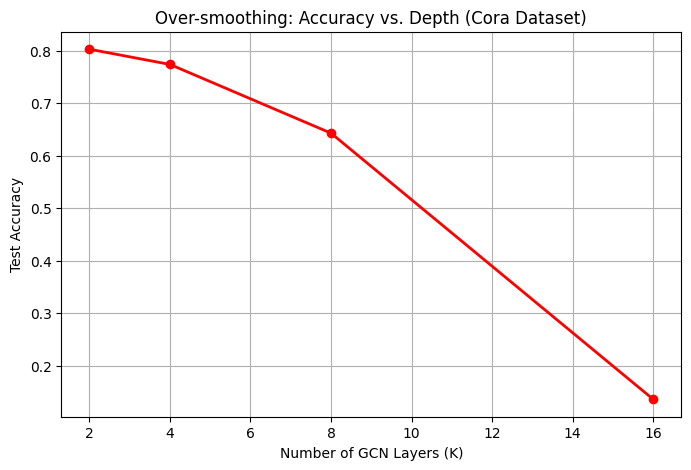

In [4]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import Planetoid
import matplotlib.pyplot as plt

dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

class GCN(torch.nn.Module):
    def __init__(self, num_layers, hidden_channels):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(dataset.num_node_features, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, dataset.num_classes))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

def train_and_test(k):
    model = GCN(num_layers=k, hidden_channels=16)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    model.eval()
    pred = model(data.x, data.edge_index).argmax(dim=1)
    correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
    return int(correct) / int(data.test_mask.sum())

k_values = [2, 4, 8, 16]
accuracies = []

for k in k_values:
    acc = train_and_test(k)
    accuracies.append(acc)
    print(f"K = {k:2} | Test Accuracy: {acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='red', linewidth=2)
plt.xlabel('Number of GCN Layers (K)')
plt.ylabel('Test Accuracy')
plt.title('Over-smoothing: Accuracy vs. Depth (Cora Dataset)')
plt.grid(True)
plt.show()